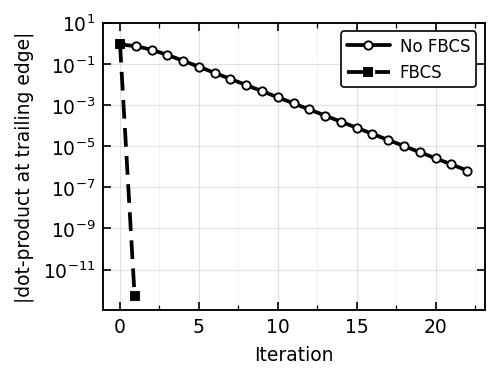

In [2]:
import numpy as np
import matplotlib.pyplot as plt


noFBCS = np.array([[0, 0.9239986272559039],
[1, 0.7667454945901773],
[2, 0.512212680811363],
[3, 0.2867115508243658],
[4, 0.14887693803468122],
[5, 0.07561588023475219],
[6, 0.03819240729138468],
[7, 0.019265766522831296],
[8, 0.009716019511738394],
[9, 0.004899823765378675],
[10, 0.0024710338877663163],
[11, 0.0012461860884694365],
[12, 0.0006284790777157934],
[13, 0.00031695734081610416],
[14, 0.0001598497247522479],
[15, 8.061642435336358e-05],
[16, 4.065701184152726e-05],
[17, 2.050442173090472e-05],
[18, 1.0340931672292442e-05],
[19, 5.2152105710634444e-06],
[20, 2.6301713743071e-06],
[21, 1.3264664033285634e-06],
[22, 6.689728111464177e-07]])

yesFBCS = np.array([[0,1], [0.9239986272559039, 5.384581669432009e-13]])

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, LogFormatterMathtext, NullFormatter, AutoMinorLocator

# -------------------- Publication defaults --------------------
mpl.rcParams.update({
    "figure.figsize": (3.4, 2.6),
    "figure.dpi": 150,
    "savefig.dpi": 600,                 # crisp raster if needed; PDF is vector anyway
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 10,
    "legend.fontsize": 8,
    "axes.linewidth": 0.9,
    "lines.linewidth": 1.8,
    "lines.markersize": 4.0,
    "lines.solid_capstyle": "round",
    "lines.solid_joinstyle": "round",
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2.2,
    "ytick.minor.size": 2.2,
})

fig, ax = plt.subplots()

# -------------------- Data unpacking (robust) --------------------
no = np.asarray(noFBCS)
x_no, y_no = no.T

yes = np.asarray(yesFBCS)
if yes.ndim == 2 and yes.shape[1] == 2:
    x_yes, y_yes = yes.T
else:
    # assumes yesFBCS is already (x, y)
    x_yes, y_yes = yesFBCS

# Ensure increasing x for nice dashes/markevery behavior
def sort_xy(x, y):
    idx = np.argsort(x)
    return np.asarray(x)[idx], np.asarray(y)[idx]

x_no, y_no = sort_xy(x_no, y_no)
x_yes, y_yes = sort_xy(x_yes, y_yes)

# -------------------- Marker strategy: show iteration "landmarks" --------------------
# show ~10–14 markers regardless of data length
def nice_markevery(x, target_markers=12):
    n = len(x)
    if n <= target_markers:
        return 1
    return max(1, n // target_markers)

me_no  = nice_markevery(x_no, 12)
me_yes = nice_markevery(x_yes, 12)

# -------------------- Plot (B/W redundant encoding) --------------------
ln1, = ax.semilogy(
    x_no, y_no,
    linestyle="-", marker="o", markevery=me_no,
    color="k",
    markerfacecolor="white", markeredgecolor="k", markeredgewidth=0.9,
    label="No FBCS",
    zorder=3,
)

ln2, = ax.semilogy(
    x_yes, y_yes,
    linestyle="--", dashes=(5, 2.5),
    marker="s", markevery=me_yes,
    color="k",
    markerfacecolor="k", markeredgecolor="k", markeredgewidth=0.9,
    label="FBCS",
    zorder=3,
)

# -------------------- Axes / ticks (scientific log look) --------------------
ax.yaxis.set_major_locator(LogLocator(base=10))
ax.yaxis.set_major_formatter(LogFormatterMathtext(base=10))   # 10^k style
ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1))
ax.yaxis.set_minor_formatter(NullFormatter())

# Minor x ticks for “iteration-scale” readability
ax.xaxis.set_minor_locator(AutoMinorLocator(2))

# -------------------- Grid (subtle, print-safe) --------------------
ax.grid(True, which="major", axis="both", linewidth=0.55, alpha=0.35, zorder=0)
ax.grid(True, which="minor", axis="both", linewidth=0.35, alpha=0.20, zorder=0)

# -------------------- Limits / padding --------------------
# tiny y padding in log space so markers don’t touch frame
y_all = np.r_[y_no, y_yes]
y_all = y_all[np.isfinite(y_all) & (y_all > 0)]
if y_all.size:
    ymin, ymax = y_all.min(), y_all.max()
    ax.set_ylim(ymin / 5.25, ymax * 10.25)

# -------------------- Labels (recommended) --------------------
ax.set_xlabel("Iteration")
ax.set_ylabel("|dot-product at trailing edge|")   # rename to your quantity

# -------------------- Legend (paper-style box) --------------------
leg = ax.legend(
    loc="best",
    frameon=True,
    edgecolor="k",
    facecolor="white",
    framealpha=1.0,
    borderpad=0.35,
    handlelength=2.6,
    handletextpad=0.6,
)
leg.get_frame().set_linewidth(0.8)

# -------------------- Optional: annotate final values (very scientific) --------------------
def annotate_last(x, y, text, dx=0.02, dy=0.0):
    ax.annotate(
        text,
        xy=(x[-1], y[-1]),
        xytext=(x[-1] + dx * (x.max() - x.min()), y[-1] * (10**dy)),
        textcoords="data",
        arrowprops=dict(arrowstyle="-", lw=0.8, color="k"),
        ha="left", va="center",
        fontsize=8,
    )

# Uncomment if you want “end state” callouts:
# annotate_last(x_no,  y_no,  f"{y_no[-1]:.2e}")
# annotate_last(x_yes, y_yes, f"{y_yes[-1]:.2e}")

fig.tight_layout()
fig.savefig(" FBCS.pdf", bbox_inches="tight", metadata={"Creator": "chatGPT"})
plt.show()
